# DeepSDF for Peptides - Minimal Implementation

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os, glob
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import open3d as o3d
from synthetic_peptides_dataset import SyntheticPeptidesDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [2]:
def compute_sdf_samples(surface_points, n_samples=4096):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(surface_points)
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.15, max_nn=50))
    pcd.orient_normals_consistent_tangent_plane(k=15)
    surface_normals = np.asarray(pcd.normals)

    tree = cKDTree(surface_points)
    near_idx = np.random.choice(len(surface_points), int(n_samples * 0.3), replace=True)
    near_points = surface_points[near_idx] + np.random.normal(0, 0.03, (len(near_idx), 3))
    bbox_min, bbox_max = surface_points.min(0) - 0.7, surface_points.max(0) + 0.7
    rand_points = np.random.uniform(bbox_min, bbox_max, (n_samples - len(near_idx), 3))
    sample_points = np.vstack([near_points, rand_points])

    distances, closest_indices = tree.query(sample_points)
    sample_vectors = sample_points - surface_points[closest_indices]
    side_indicators = np.sum(sample_vectors * surface_normals[closest_indices], axis=1)
    signed_distances = np.where((side_indicators < 0) & (distances < 0.05), -distances, distances)
    return sample_points, signed_distances


class SDFDataset(Dataset):
    def __init__(self, peptide_dataset, n_samples=4096):
        self.peptide_dataset = peptide_dataset
        self.n_samples = n_samples

    def __len__(self):
        return len(self.peptide_dataset)

    def __getitem__(self, idx):
        surface = self.peptide_dataset[idx]["points"].numpy()
        coords, sdf = compute_sdf_samples(surface, self.n_samples)
        return torch.tensor(coords, dtype=torch.float32), torch.tensor(sdf, dtype=torch.float32), idx


In [3]:
try:
    test_data = SyntheticPeptidesDataset('./data/synthetic_peptides_split/train', num_files=1, structure_types=['nanotubes'])
except:
    test_data = SyntheticPeptidesDataset('./data/synthetic_peptides', num_files=1)

surface_np = test_data[0]["points"].numpy()
sample_coords, sample_sdf = compute_sdf_samples(surface_np, n_samples=10000)

inside_mask = sample_sdf < -0.02
surface_mask = np.abs(sample_sdf) <= 0.02
outside_mask = sample_sdf > 0.02
print(f"Inside: {np.sum(inside_mask)} ({np.sum(inside_mask)/len(sample_sdf)*100:.1f}%)  "
      f"Surface: {np.sum(surface_mask)} ({np.sum(surface_mask)/len(sample_sdf)*100:.1f}%)  "
      f"Outside: {np.sum(outside_mask)} ({np.sum(outside_mask)/len(sample_sdf)*100:.1f}%)  "
      f"SDF: [{sample_sdf.min():.3f}, {sample_sdf.max():.3f}]")

fig = go.Figure([
    go.Scatter3d(x=surface_np[:,0], y=surface_np[:,1], z=surface_np[:,2],
                 mode='markers', marker=dict(size=2, color='lightgray', opacity=0.3), name='Surface'),
    go.Scatter3d(x=sample_coords[:,0], y=sample_coords[:,1], z=sample_coords[:,2],
                 mode='markers',
                 marker=dict(size=2, color=sample_sdf, colorscale='RdBu_r', cmin=-0.2, cmax=0.2,
                             colorbar=dict(title="SDF", thickness=15, len=0.7), showscale=True),
                 name='SDF Samples',
                 hovertemplate='SDF: %{marker.color:.3f}<extra></extra>')
])
fig.update_layout(title='SDF Samples (Red=Inside, Blue=Outside)', scene=dict(aspectmode='data'), height=600)
fig.show()


Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: nanotubes
Dataset ready: 1 files, target_points=None, normalize=True
Inside: 558 (5.6%)  Surface: 1796 (18.0%)  Outside: 7646 (76.5%)  SDF: [-0.050, 1.371]


In [4]:
class DeepSDF(nn.Module):
    def __init__(self, num_shapes, latent_dim=128, hidden_dim=256):
        super().__init__()
        self.latent_codes = nn.Embedding(num_shapes, latent_dim)
        
        # Decoder network
        self.layers = nn.ModuleList([
            nn.Linear(3 + latent_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim + 3 + latent_dim, hidden_dim),  # Skip connection
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim, 1, bias=False)
        ])
        
        # Initialize
        nn.init.normal_(self.latent_codes.weight, 0, 0.01)
        for layer in self.layers[:-1]:
            nn.init.xavier_normal_(layer.weight)
        nn.init.normal_(self.layers[-1].weight, 0, 1e-5)
    
    def forward(self, coords, shape_indices):
        B, N, _ = coords.shape
        latent = self.latent_codes(shape_indices).unsqueeze(1).expand(B, N, -1)
        x_input = torch.cat([coords, latent], dim=-1)
        
        x = F.relu(self.layers[0](x_input))
        x = F.relu(self.layers[1](x))
        x = F.relu(self.layers[2](x))
        x = F.relu(self.layers[3](torch.cat([x, x_input], dim=-1)))  # Skip
        x = F.relu(self.layers[4](x))
        return self.layers[5](x)

def sdf_loss(pred, target, latent_codes, lambda_reg=1e-4):
    """
    Enhanced SDF loss for hollow objects.
    Emphasizes both surface accuracy and inside/outside distinction.
    """
    pred_flat = pred.squeeze()
    
    # Multi-tier weighting for better hollow object learning
    surface_weight = 10.0  # Very close to surface
    near_surface_weight = 3.0  # Moderately close
    far_weight = 1.0  # Far from surface
    
    # Classify points by distance to surface
    abs_target = torch.abs(target)
    surface_mask = abs_target < 0.02      # Very close to surface
    near_mask = (abs_target >= 0.02) & (abs_target < 0.1)  # Near surface
    far_mask = abs_target >= 0.1          # Far from surface
    
    # Apply different weights
    weights = torch.ones_like(target)
    weights[surface_mask] = surface_weight
    weights[near_mask] = near_surface_weight  
    weights[far_mask] = far_weight
    
    # L1 loss with sign preservation (important for inside/outside)
    sdf_error = torch.abs(pred_flat - target)
    weighted_loss = torch.mean(weights * sdf_error)
    
    # Regularization
    reg_loss = lambda_reg * torch.mean(latent_codes ** 2)
    
    # Add small penalty for sign errors (helps with inside/outside learning)
    sign_penalty = 0.1 * torch.mean(torch.relu(-pred_flat * target))  # Penalty when signs differ
    
    return weighted_loss + reg_loss + sign_penalty

In [5]:
CONFIG = {'epochs': 500, 'batch_size': 1, 'lr': 5e-5, 'latent_lr': 1e-4}

try:
    peptide_data = SyntheticPeptidesDataset('./data/synthetic_peptides_split/train', num_files=1, structure_types=['nanotubes'])
except:
    peptide_data = SyntheticPeptidesDataset('./data/synthetic_peptides', num_files=10)

train_data = SDFDataset(peptide_data, n_samples=6144)
train_loader = DataLoader(train_data, batch_size=CONFIG['batch_size'], shuffle=True)
print(f"Training on {len(train_data)} shapes")

model = DeepSDF(len(train_data)).to(device)
decoder_opt = torch.optim.Adam(model.layers.parameters(), lr=CONFIG['lr'])
latent_opt = torch.optim.Adam(model.latent_codes.parameters(), lr=CONFIG['latent_lr'])
losses = []


Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: nanotubes
Dataset ready: 1 files, target_points=None, normalize=True
Training on 1 shapes


In [6]:
# Enhanced training loop with diagnostics
model.train()
print("🚀 Starting training with Open3D normal-based SDF computation...")

for epoch in range(CONFIG['epochs']):
    epoch_loss = 0
    for coords, sdf_vals, indices in train_loader:
        coords, sdf_vals, indices = coords.to(device), sdf_vals.to(device), indices.to(device)
        
        decoder_opt.zero_grad()
        latent_opt.zero_grad()
        
        pred_sdf = model(coords, indices)
        latent_codes = model.latent_codes(indices)
        loss = sdf_loss(pred_sdf, sdf_vals, latent_codes)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        decoder_opt.step()
        latent_opt.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    
    # Enhanced progress reporting with SDF diagnostics
    if epoch % 50 == 0:
        model.eval()
        with torch.no_grad():
            # Quick evaluation on training data
            sample_coords, sample_sdf, sample_idx = next(iter(train_loader))
            sample_coords, sample_sdf = sample_coords.to(device), sample_sdf.to(device)
            pred_sample = model(sample_coords, torch.tensor([sample_idx], device=device))
            
            # Compute accuracy metrics - ensure all tensors are properly flattened
            pred_flat = pred_sample.view(-1)  # Force flatten
            sdf_flat = sample_sdf.view(-1)    # Force flatten
            
            signs_correct = torch.sum((pred_flat * sdf_flat) > 0).float() / len(sdf_flat)
            
            # Surface error - check if there are surface points first
            surface_mask = torch.abs(sdf_flat) < 0.05
            if torch.sum(surface_mask) > 0:
                surface_error = torch.mean(torch.abs(pred_flat[surface_mask]))
                print(f"Epoch {epoch:4d}: Loss = {avg_loss:.6f} | Sign Accuracy = {signs_correct:.3f} | Surface Error = {surface_error:.4f}")
            else:
                print(f"Epoch {epoch:4d}: Loss = {avg_loss:.6f} | Sign Accuracy = {signs_correct:.3f} | No surface points")
        model.train()
    elif epoch % 25 == 0:
        print(f"Epoch {epoch:4d}: Loss = {avg_loss:.6f}")

print(f"🎉 Training complete! Final loss: {losses[-1]:.6f}")

# Save enhanced model
Path('checkpoints').mkdir(exist_ok=True)
torch.save(model.state_dict(), 'checkpoints/deepsdf_minimal.pth')
print("✅ Enhanced DeepSDF model saved!")

🚀 Starting training with Open3D normal-based SDF computation...
Epoch    0: Loss = 0.540299 | Sign Accuracy = 0.855 | Surface Error = 0.0003
Epoch   25: Loss = 0.526880
Epoch   50: Loss = 0.517182 | Sign Accuracy = 0.844 | Surface Error = 0.0159
Epoch   75: Loss = 0.503448
Epoch  100: Loss = 0.438099 | Sign Accuracy = 0.852 | Surface Error = 0.0227
Epoch  125: Loss = 0.230223
Epoch  150: Loss = 0.079525 | Sign Accuracy = 0.854 | Surface Error = 0.0071
Epoch  175: Loss = 0.059429
Epoch  200: Loss = 0.052938 | Sign Accuracy = 0.878 | Surface Error = 0.0067
Epoch  225: Loss = 0.047821
Epoch  250: Loss = 0.044686 | Sign Accuracy = 0.881 | Surface Error = 0.0082
Epoch  275: Loss = 0.041783
Epoch  300: Loss = 0.039195 | Sign Accuracy = 0.896 | Surface Error = 0.0100
Epoch  325: Loss = 0.037690
Epoch  350: Loss = 0.037568 | Sign Accuracy = 0.909 | Surface Error = 0.0116
Epoch  375: Loss = 0.034933
Epoch  400: Loss = 0.034465 | Sign Accuracy = 0.897 | Surface Error = 0.0117
Epoch  425: Loss = 

In [7]:
# Test hollow structure learning
print("🔍 Testing hollow structure learning...")

model.eval()
with torch.no_grad():
    # Get a test sample
    sample_coords, sample_sdf, sample_idx = next(iter(train_loader))
    sample_coords = sample_coords.to(device)
    shape_idx_tensor = torch.tensor([sample_idx], device=device)
    
    # Predict SDF values
    pred_sdf = model(sample_coords, shape_idx_tensor).cpu().squeeze().numpy()
    true_sdf = sample_sdf.numpy()
    coords_np = sample_coords.cpu().squeeze().numpy()
    
    # Analyze inside vs outside predictions
    inside_mask = true_sdf < -0.05  # True inside points
    outside_mask = true_sdf > 0.05  # True outside points
    surface_mask = np.abs(true_sdf) <= 0.05  # Surface points
    
    if np.sum(inside_mask) > 0 and np.sum(outside_mask) > 0:
        inside_pred_avg = np.mean(pred_sdf[inside_mask])
        outside_pred_avg = np.mean(pred_sdf[outside_mask])
        surface_pred_avg = np.mean(np.abs(pred_sdf[surface_mask]))
        
        print(f"📊 SDF Analysis:")
        print(f"   Inside points:  True={np.mean(true_sdf[inside_mask]):.3f}, Pred={inside_pred_avg:.3f}")
        print(f"   Outside points: True={np.mean(true_sdf[outside_mask]):.3f}, Pred={outside_pred_avg:.3f}")
        print(f"   Surface points: Avg |error|={surface_pred_avg:.3f}")
        
        # Check if model learned inside/outside correctly
        inside_correct = inside_pred_avg < 0
        outside_correct = outside_pred_avg > 0
        
        if inside_correct and outside_correct:
            print("✅ Model correctly learned inside/outside distinction!")
        else:
            print(f"⚠️ Model may have issues: Inside negative? {inside_correct}, Outside positive? {outside_correct}")
    else:
        print("⚠️ Not enough inside/outside points to analyze")
    
    print(f"🎯 Overall sign accuracy: {np.mean((pred_sdf * true_sdf) > 0):.3f}")

🔍 Testing hollow structure learning...
⚠️ Not enough inside/outside points to analyze
🎯 Overall sign accuracy: 0.905


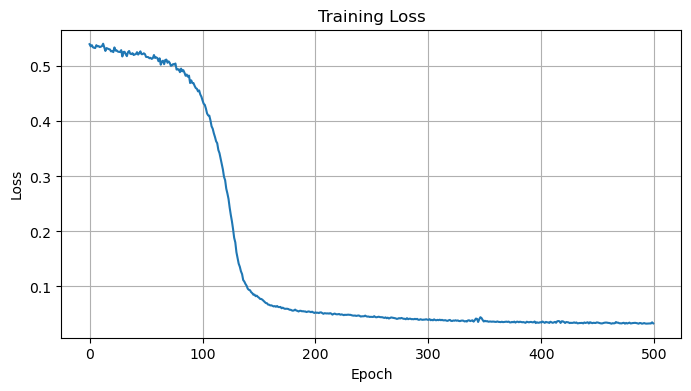

SDF range: [-0.028, 1.753]
Near-surface points (|sdf| < 0.1): 123

✅ Minimal DeepSDF training complete!


In [8]:
# Quick evaluation
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Test SDF evaluation
model.eval()
with torch.no_grad():
    test_coords = torch.randn(1, 1000, 3).to(device) * 0.5
    test_sdf = model(test_coords, torch.tensor([0], device=device))
    print(f"SDF range: [{test_sdf.min():.3f}, {test_sdf.max():.3f}]")
    print(f"Near-surface points (|sdf| < 0.1): {torch.sum(torch.abs(test_sdf) < 0.1).item()}")

print("\n✅ Minimal DeepSDF training complete!")

In [9]:
model.eval()
with torch.no_grad():
    original_points = peptide_data[0]["points"].numpy()

    resolution = 64
    grid_range = 1.2
    x = np.linspace(-grid_range, grid_range, resolution)
    y = np.linspace(-grid_range, grid_range, resolution)
    z = np.linspace(-grid_range, grid_range, resolution)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    grid_coords = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=-1)
    grid_tensor = torch.tensor(grid_coords, dtype=torch.float32, device=device).unsqueeze(0)
    shape_idx_tensor = torch.tensor([0], device=device)

    sdf_values = []
    for i in range(0, len(grid_coords), 10000):
        sdf_values.append(model(grid_tensor[:, i:i+10000], shape_idx_tensor).cpu().numpy())
    sdf_grid = np.concatenate(sdf_values, axis=1).reshape(resolution, resolution, resolution)

    surf_idx = np.where(np.abs(sdf_grid) < 0.05)
    reconstructed_points = np.column_stack([x[surf_idx[0]], y[surf_idx[1]], z[surf_idx[2]]])

    fig = make_subplots(rows=1, cols=3, specs=[[{'type': 'scatter3d'}]*3],
                        subplot_titles=['Original', 'Reconstructed', 'Overlay'])
    fig.add_trace(go.Scatter3d(x=original_points[:,0], y=original_points[:,1], z=original_points[:,2],
                               mode='markers', marker=dict(size=1, color='blue'), name='Original'), row=1, col=1)
    if len(reconstructed_points) > 0:
        fig.add_trace(go.Scatter3d(x=reconstructed_points[:,0], y=reconstructed_points[:,1], z=reconstructed_points[:,2],
                                   mode='markers', marker=dict(size=1, color='red'), name='Recon'), row=1, col=2)
        fig.add_trace(go.Scatter3d(x=original_points[:,0], y=original_points[:,1], z=original_points[:,2],
                                   mode='markers', marker=dict(size=1, color='blue', opacity=0.4), showlegend=False), row=1, col=3)
        fig.add_trace(go.Scatter3d(x=reconstructed_points[:,0], y=reconstructed_points[:,1], z=reconstructed_points[:,2],
                                   mode='markers', marker=dict(size=1, color='red', opacity=0.4), showlegend=False), row=1, col=3)
    fig.show()
    print(f"Original: {len(original_points):,}  Reconstructed: {len(reconstructed_points):,}  "
          f"SDF range: [{sdf_grid.min():.3f}, {sdf_grid.max():.3f}]")


Original: 3,000  Reconstructed: 4,175  SDF range: [-0.028, 1.826]
